# 1. importing

In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

2026-05-07 13:06:39.191441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778159199.399584      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778159199.465042      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778159199.942117      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778159199.942150      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778159199.942152      57 computation_placer.cc:177] computation placer alr

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path

In [5]:
print (tf.__version__)

2.19.0


In [6]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 2. Load dataset testing & Distribusi data test

In [7]:
TRAIN_DIR = Path("/kaggle/input/datasets/ilhamcaa/dataset-project-dicoding/Data/train")

# Defaultdict list agar otomatis membuat list kosong jika kunci (label) belum ada
kumpulan_variabel = defaultdict(list)

# Iterasi seluruh gambar
for path_gambar in TRAIN_DIR.rglob("*.jpg"):
    label = path_gambar.parent.name
    
    # Masukkan path ke dalam label yang sesuai
    kumpulan_variabel[label].append(str(path_gambar))

# Sekarang Anda punya variabel dinamis:
print(f"Isi variabel fake_mask: {len(kumpulan_variabel['fake_mask'])} file.")

print(f"Isi variabel fake_mask: {len(kumpulan_variabel['realperson'])} file.")

Isi variabel fake_mask: 729 file.
Isi variabel fake_mask: 2331 file.


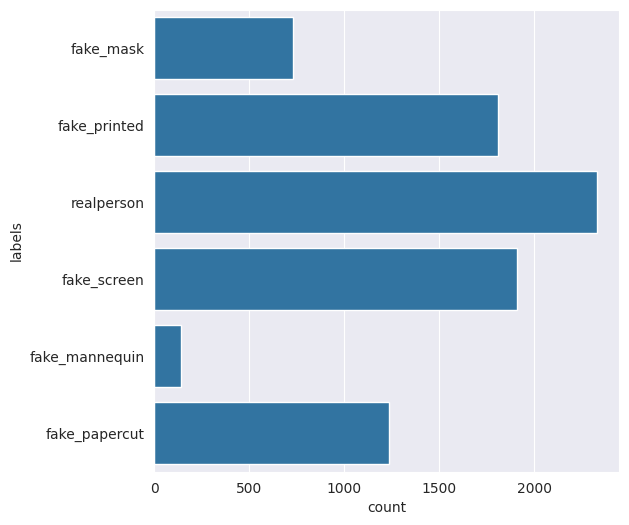

In [8]:
# Extract file names from full paths
TRAIN_DIR = Path("/kaggle/input/datasets/ilhamcaa/dataset-project-dicoding/Data/train")
full_path = []
file_name = []
labels = []

for label in TRAIN_DIR.iterdir():
    if label.is_dir():
        for image_file in label.glob("*.jpg"):
            full_path.append(str(image_file))
            file_name.append(image_file.name)
            labels.append(label.name)

distribution_train = pd.DataFrame({"path": full_path, 'file_name': file_name, "labels": labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize=(6, 6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

Karena data test tidak seimbang, kita akan melakukan data augmentation agar menghasilkan variasi dari data yang ada untuk kelas minoritas agar jumlahnya setara dengan kelas mayoritas. Kita akan menggunakan ImageDataGenerator dari Keras untuk melakukan augmentasi data.

Hasil augmentasi data akan disimpan ke dalam folder baru bernama "Data/test_augmented". Kita akan membuat subfolder untuk setiap kelas di dalam folder tersebut.

## Model Augmentation

In [9]:
import os
import cv2
import random
from random import sample
import numpy as np
import shutil
from pathlib import Path
from collections import defaultdict
from skimage.transform import AffineTransform, warp
from skimage.exposure import adjust_gamma

# ========================================================
# 1. DEFINISI FUNGSI AUGMENTASI & DICTIONARY
# ========================================================
def add_brightness(img):
    img = cv2.resize(img, (224,224))
    img = adjust_gamma(img, gamma=0.5, gain=1)
    return img
 
def blur_image(img):
    img = cv2.resize(img, (224,224))
    return cv2.GaussianBlur(img, (9,9), 0)
 
def sheared(img):
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image
 
def warp_shift(img):
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(translation=(0,40))
    warp_image = warp(img, transform, mode="wrap")
    return warp_image

transformations = {
    "brightness": add_brightness,
    "blur": blur_image,
    "shear": sheared,
    "warp": warp_shift
}

# ========================================================
# 2. SETUP PATH & PENGUMPULAN DATA
# ========================================================
TRAIN_DIR = Path("/kaggle/input/datasets/ilhamcaa/dataset-project-dicoding/Data/train")
TRAIN_AUGMENTED_DIR = Path("/kaggle/working/Data/train_augmented")


kumpulan_variabel = defaultdict(list)
for path_gambar in TRAIN_DIR.rglob("*.jpg"):
    label = path_gambar.parent.name
    kumpulan_variabel[label].append(str(path_gambar))

# Bersihkan folder augmented jika sebelumnya gagal di tengah jalan
if TRAIN_AUGMENTED_DIR.exists():
    shutil.rmtree(TRAIN_AUGMENTED_DIR)
TRAIN_AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

# Set target jumlah gambar
TARGET_COUNT_PER_CLASS = 2500

# ========================================================
# 3. PROSES PEMINDAHAN & AUGMENTASI
# ========================================================
for label_path in TRAIN_DIR.iterdir():
    if not label_path.is_dir():
        continue 
        
    label_name = label_path.name 
    label_dir = TRAIN_AUGMENTED_DIR / label_name
    label_dir.mkdir(parents=True, exist_ok=True)

    images_for_label = kumpulan_variabel.get(label_name, [])
    current_count = len(images_for_label)

    if current_count == 0:
        print(f"Skip {label_name}: tidak ada gambar.")
        continue

    # Tentukan gambar sumber
    if current_count >= TARGET_COUNT_PER_CLASS:
        selected_images = sample(images_for_label, TARGET_COUNT_PER_CLASS)
        images_to_augment = []
    else:
        selected_images = list(images_for_label)
        augment_needed = TARGET_COUNT_PER_CLASS - current_count
        images_to_augment = [random.choice(images_for_label) for _ in range(augment_needed)]

    print(f"Memproses {label_name}... (Target: {TARGET_COUNT_PER_CLASS})")

    # Simpan gambar asli
    for idx, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        if img is None: continue
        filename = f"{label_name}_orig_{idx}.jpg"
        output_path = label_dir / filename
        cv2.imwrite(str(output_path), img)

    # Apply augmentasi untuk kekurangan gambar
    for idx, img_path in enumerate(images_to_augment):
        img = cv2.imread(img_path)
        if img is None: continue

        # Pilih transformasi random
        transform_name = random.choice(list(transformations.keys()))
        augmented_img = transformations[transform_name](img)

        filename = f"{label_name}_augmented_{idx}.jpg"
        output_path = label_dir / filename
        # Hasil dari skimage warp biasanya float 0.0-1.0, jadi harus dikali 255
        cv2.imwrite(str(output_path), (augmented_img * 255).astype(np.uint8))

    final_count = len(list(label_dir.glob("*.jpg")))
    print(f"Selesai {label_name}: {current_count} -> {final_count} gambar")

Memproses fake_mask... (Target: 2500)
Selesai fake_mask: 729 -> 2500 gambar
Memproses fake_printed... (Target: 2500)
Selesai fake_printed: 1809 -> 2500 gambar
Memproses realperson... (Target: 2500)
Selesai realperson: 2331 -> 2500 gambar
Memproses fake_screen... (Target: 2500)
Selesai fake_screen: 1911 -> 2500 gambar
Memproses fake_mannequin... (Target: 2500)
Selesai fake_mannequin: 142 -> 2500 gambar
Memproses fake_papercut... (Target: 2500)
Selesai fake_papercut: 1237 -> 2500 gambar


# Model Training Menggunakan Resnet50

# ==========================================
# 2. DATA LOADING & PREPARATION
# ==========================================
Memuat data dari direktori yang telah dibersihkan ke dalam objek TensorFlow Dataset.

In [10]:
import os
import shutil
import tensorflow as tf
from pathlib import Path

# ==========================================
# A. PARAMETER & PATH
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

ORIGINAL_VAL_DIR = "/kaggle/input/datasets/ilhamcaa/dataset-project-dicoding/Data/val"
TRAIN_DIR = "/kaggle/working/Data/train_augmented"
VAL_DIR = "/kaggle/working/val_clean_training"

# ==========================================
# B. PERSIAPAN & PEMBERSIHAN FOLDER (ANTI-ERROR)
# ==========================================
print("Menyiapkan dan membersihkan direktori data...")

# 1. Siapkan folder validasi agar tidak NotFoundError
if not os.path.exists(VAL_DIR):
    shutil.copytree(ORIGINAL_VAL_DIR, VAL_DIR)
    print(f"✅ Berhasil menyalin data validasi ke {VAL_DIR}")

# 2. Fungsi Pembersih Ketat (Mencegah InvalidArgumentError)
def deep_clean_directory(directory):
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    removed = 0
    
    # Hapus folder tersembunyi bawaan Kaggle/Jupyter
    for root, dirs, files in os.walk(directory, topdown=False):
        for name in dirs:
            if name == '.ipynb_checkpoints':
                shutil.rmtree(os.path.join(root, name))
                
    # Hapus file dengan ekstensi salah atau format data rusak
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            ext = os.path.splitext(file)[1].lower()
            
            # Cek ekstensi
            if ext not in valid_exts:
                os.remove(file_path)
                removed += 1
                continue
                
            # Uji baca ketat menggunakan engine TensorFlow
            try:
                img_bytes = tf.io.read_file(file_path)
                _ = tf.io.decode_image(img_bytes, expand_animations=False)
            except Exception:
                os.remove(file_path)
                removed += 1
                
    if removed > 0:
        print(f"   -> Dihapus {removed} file bermasalah di {directory}")
    else:
        print(f"   -> {directory} sudah bersih.")

print("Memeriksa Data Latih (Train)...")
deep_clean_directory(TRAIN_DIR)

print("Memeriksa Data Validasi (Val)...")
deep_clean_directory(VAL_DIR)

# ==========================================
# C. MEMUAT DATASET
# ==========================================
print("\nMemuat Data Latih...")
train_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nMemuat Data Validasi...")
val_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode="categorical",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_resnet.class_names
num_classes = len(class_names)

# Optimasi Pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds_resnet = train_ds_resnet.cache().prefetch(AUTOTUNE)
val_ds_resnet = val_ds_resnet.cache().prefetch(AUTOTUNE)

Menyiapkan dan membersihkan direktori data...
✅ Berhasil menyalin data validasi ke /kaggle/working/val_clean_training
Memeriksa Data Latih (Train)...


I0000 00:00:1778159450.557873      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778159450.563796      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


   -> /kaggle/working/Data/train_augmented sudah bersih.
Memeriksa Data Validasi (Val)...
   -> Dihapus 1 file bermasalah di /kaggle/working/val_clean_training

Memuat Data Latih...
Found 15000 files belonging to 6 classes.

Memuat Data Validasi...
Found 1748 files belonging to 6 classes.


# ==========================================
# 3. MODEL ARCHITECTURE (FUNCTIONAL API)
# ==========================================
Membangun model menggunakan ResNet50 sebagai base model. Kita menggunakan Functional API untuk fleksibilitas arsitektur.

In [11]:
from tensorflow.keras import layers

print(f"Membangun model untuk {num_classes} kelas: {class_names}")

# 1. Load Pre-trained Model (ResNet50)
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False # Freeze base model untuk tahap awal

# 2. Rangkaian Functional API
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
# Preprocessing khusus ResNet50 dimasukkan ke dalam model
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
# Layer output menyesuaikan jumlah kelas yang ada
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_resnet50 = tf.keras.Model(inputs, outputs, name="resnet50_classifier")
model_resnet50.summary()

Membangun model untuk 6 kelas: ['fake_mannequin', 'fake_mask', 'fake_papercut', 'fake_printed', 'fake_screen', 'realperson']
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6)         │     12,294 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# ==========================================
# 4. CUSTOM COMPONENT & MODEL TRAINING
# ==========================================
Implementasi callback kustom (TargetAccuracyCallback) untuk menghentikan training secara otomatis jika target akurasi tercapai, lalu melakukan pelatihan model (Feature Extraction dan Fine-Tuning).

In [12]:
# Definisi Custom Callback
class TargetAccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_val_acc):
        super(TargetAccuracyCallback, self).__init__()
        self.target_val_acc = target_val_acc

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= self.target_val_acc:
            print(f"\n[INFO] Target Akurasi {self.target_val_acc} tercapai. Training dihentikan otomatis!")
            self.model.stop_training = True

# Menyiapkan List Callbacks
callbacks = [
    TargetAccuracyCallback(target_val_acc=0.98), # Target Akurasi Validasi 98%
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("/kaggle/working/best_model.keras", monitor="val_f1_score", mode="max", save_best_only=True)
]

# Tahap 1: Training Head (Feature Extraction)
model_resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.F1Score(average='macro', name='f1_score')]
)

print("\n--- Memulai Training Tahap 1 (Head Only) ---")
model_resnet50.fit(train_ds_resnet, validation_data=val_ds_resnet, epochs=10, callbacks=callbacks)

# Tahap 2: Fine-tuning
print("\n--- Memulai Fine-tuning Tahap 2 ---")
base_model.trainable = True
# Bekukan sebagian layer awal, buka sisanya
for layer in base_model.layers[:-30]: 
    layer.trainable = False

# Recompile dengan Learning Rate lebih kecil
model_resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.F1Score(average='macro', name='f1_score')]
)
model_resnet50.fit(train_ds_resnet, validation_data=val_ds_resnet, epochs=5, callbacks=callbacks)

# Simpan Model Final (Kriteria: Export Model .keras)
model_resnet50.save("/kaggle/working/model_final.keras")
print("\nModel disimpan di /kaggle/working/model_final.keras")


--- Memulai Training Tahap 1 (Head Only) ---
Epoch 1/10


I0000 00:00:1778159502.441902     132 service.cc:152] XLA service 0x7fbf800493f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778159502.441960     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778159502.441968     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778159504.430423     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/469 ━━━━━━━━━━━━━━━━━━━━ 1:49:21 14s/step - accuracy: 0.1875 - f1_score: 0.1169 - loss: 2.7406

I0000 00:00:1778159509.686601     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 138ms/step - accuracy: 0.6276 - f1_score: 0.6264 - loss: 1.0196 - val_accuracy: 0.8501 - val_f1_score: 0.8016 - val_loss: 0.4346
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.8440 - f1_score: 0.8437 - loss: 0.4384 - val_accuracy: 0.8656 - val_f1_score: 0.8230 - val_loss: 0.3918
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - accuracy: 0.8663 - f1_score: 0.8661 - loss: 0.3800 - val_accuracy: 0.8673 - val_f1_score: 0.8233 - val_loss: 0.3731
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.8799 - f1_score: 0.8797 - loss: 0.3429 - val_accuracy: 0.8810 - val_f1_score: 0.8508 - val_loss: 0.3510
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.8804 - f1_score: 0.8803 - loss: 0.3351 - val_accuracy: 0.8713 - val_f1_score: 0.8308 - val_loss: 0.3812
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.8905 - f1_score: 0.8904 - loss: 0.3105 - val_accuracy: 0.8839 - val_f1_score: 0.83

# ==========================================
# 5. INFERENCE (PREDIKSI GAMBAR BARU)
# ==========================================
Melakukan pengujian model yang telah dilatih (.keras) terhadap gambar untuk melihat kinerja model di dunia nyata.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Tentukan gambar yang ingin diuji (Ganti path ini)
img_path = '/kaggle/input/datasets/ilhamcaa/dataset-project-dicoding/Data/val/fake_mask/contoh_gambar.jpg' 

def test_inference(img_path):
    print("Memuat model untuk Inference...")
    model = tf.keras.models.load_model("/kaggle/working/model_final.keras")
    
    # 1. Muat gambar dan resize
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Konversi ke array
    x = image.img_to_array(img)
    
    # 3. Tambahkan dimensi batch
    x = np.expand_dims(x, axis=0)
    
    # 4. Lakukan Prediksi
    preds = model.predict(x)
    
    # 5. Ekstrak Hasil
    predicted_idx = np.argmax(preds[0])
    confidence = np.max(preds[0]) * 100
    predicted_label = class_names[predicted_idx]
    
    # Tampilkan Gambar dan Hasil Prediksi
    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Jalankan Fungsi (Hilangkan tanda pagar jika path gambar sudah benar)
# test_inference(img_path)

## Keras Export

In [14]:
import os

# Tentukan path folder tujuan
save_dir = '/kaggle/working/model'

# Buat folder jika belum ada
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Direktori {save_dir} berhasil dibuat.")


# Menyimpan model final ke dalam folder /kaggle/working/model/
model_resnet50.save(os.path.join(save_dir, 'model_final.keras'))
print(f"Model final disimpan di: {save_dir}/model_final.keras")

Direktori /kaggle/working/model berhasil dibuat.
Model final disimpan di: /kaggle/working/model/model_final.keras


## Komparasi Model dengan Validation

1. Memuat model...

2. Menyiapkan dan membersihkan data validasi secara ketat...
   Pembersihan selesai. 1 file bermasalah/tersembunyi dihapus.

3. Memuat dataset...
Found 1748 files belonging to 6 classes.
   Mengekstraksi label asli dan menjalankan prediksi...
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step

4. Menghasilkan Laporan Evaluasi...

--- CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

fake_mannequin       0.76      0.73      0.75        30
     fake_mask       0.90      0.90      0.90       155
 fake_papercut       0.93      0.92      0.92       265
  fake_printed       0.92      0.93      0.92       388
   fake_screen       0.97      0.95      0.96       410
    realperson       0.94      0.96      0.95       500

      accuracy                           0.93      1748
     macro avg       0.90      0.90      0.90      1748
  weighted avg       0.93      0.93      0.93      1748


--- CONFUSION MATRIX ---


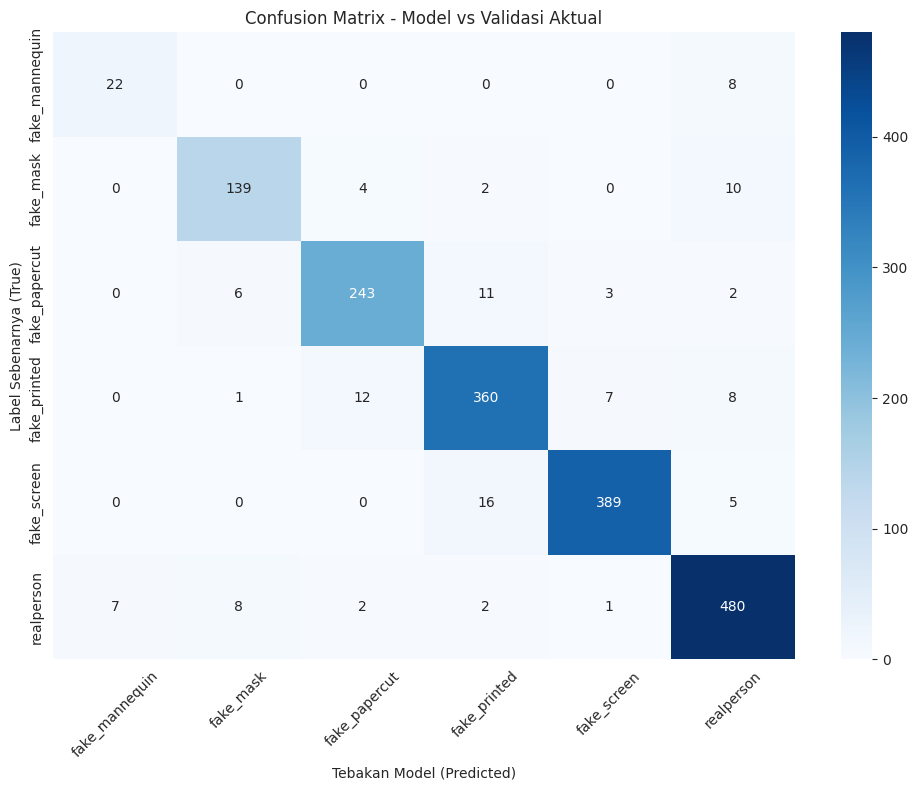

In [15]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP PATH DAN MUAT MODEL
# ==========================================
MODEL_PATH = '/kaggle/working/model/model_final.keras'
VAL_DIR_ORIGINAL = '/kaggle/input/datasets/ilhamcaa/dataset-project-dicoding/Data/val'
VAL_DIR_CLEAN = '/kaggle/working/val_clean_eval_v2' # Menggunakan folder baru
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("1. Memuat model...")
model = load_model(MODEL_PATH)

# ==========================================
# 2. PEMBERSIHAN DATA EKSTRA KETAT
# ==========================================
print("\n2. Menyiapkan dan membersihkan data validasi secara ketat...")
if os.path.exists(VAL_DIR_CLEAN):
    shutil.rmtree(VAL_DIR_CLEAN)
shutil.copytree(VAL_DIR_ORIGINAL, VAL_DIR_CLEAN)

# Hapus folder .ipynb_checkpoints bawaan Kaggle
for root, dirs, files in os.walk(VAL_DIR_CLEAN, topdown=False):
    for name in dirs:
        if name == '.ipynb_checkpoints':
            shutil.rmtree(os.path.join(root, name))

# Ekstensi yang diizinkan oleh TensorFlow
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
removed_count = 0

for root, dirs, files in os.walk(VAL_DIR_CLEAN):
    for file in files:
        file_path = os.path.join(root, file)
        ext = os.path.splitext(file)[1].lower()
        
        # Hapus jika ekstensi tidak valid
        if ext not in valid_extensions:
            os.remove(file_path)
            removed_count += 1
            continue
            
        # Uji baca langsung dengan mesin TensorFlow
        try:
            img_bytes = tf.io.read_file(file_path)
            _ = tf.io.decode_image(img_bytes, expand_animations=False)
        except Exception:
            os.remove(file_path)
            removed_count += 1

print(f"   Pembersihan selesai. {removed_count} file bermasalah/tersembunyi dihapus.")

# ==========================================
# 3. PEMUATAN DATASET & PREDIKSI
# ==========================================
print("\n3. Memuat dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR_CLEAN,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # PENTING: Jangan diacak
)

class_names = val_ds.class_names

print("   Mengekstraksi label asli dan menjalankan prediksi...")
y_true_classes = []
for images, labels in val_ds:
    y_true_classes.extend(np.argmax(labels.numpy(), axis=1))
y_true_classes = np.array(y_true_classes)

predictions = model.predict(val_ds)
y_pred_classes = np.argmax(predictions, axis=1)

# ==========================================
# 4. LAPORAN F1-SCORE DAN CONFUSION MATRIX
# ==========================================
print("\n4. Menghasilkan Laporan Evaluasi...")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Model vs Validasi Aktual')
plt.ylabel('Label Sebenarnya (True)')
plt.xlabel('Tebakan Model (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# INFERENCE MODEL (PREDIKSI GAMBAR BARU)
# ==========================================
# Melakukan pengujian model yang telah dilatih (.keras) terhadap satu gambar acak
# dari sistem untuk melihat kinerja model di dunia nyata.

Memuat model untuk Inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


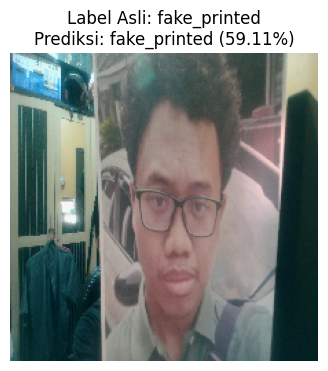

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


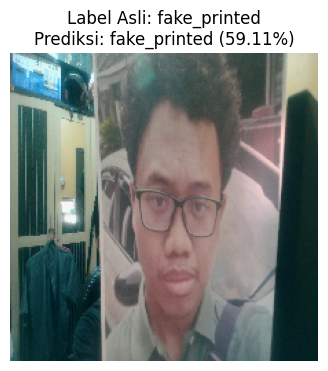

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


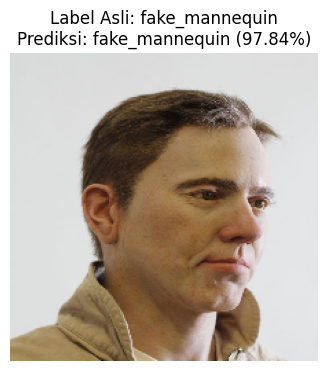

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


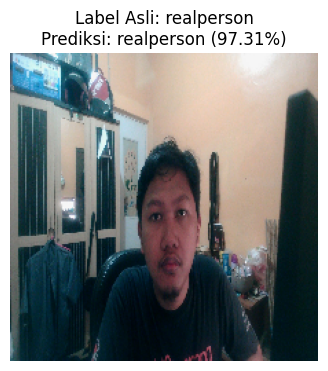

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


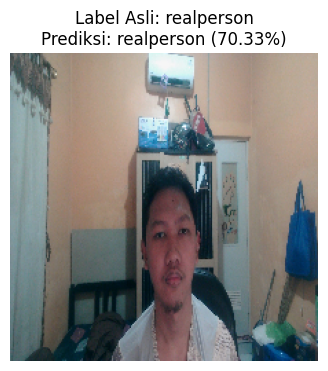

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


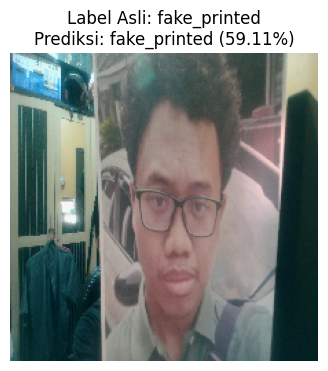

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


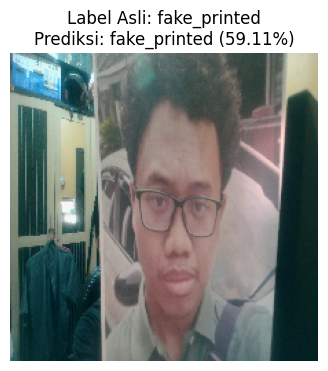

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


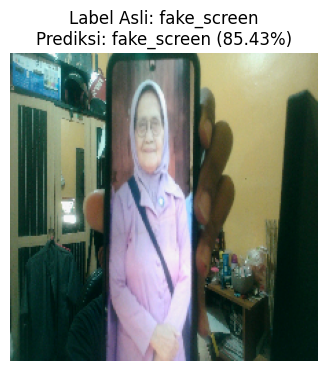

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


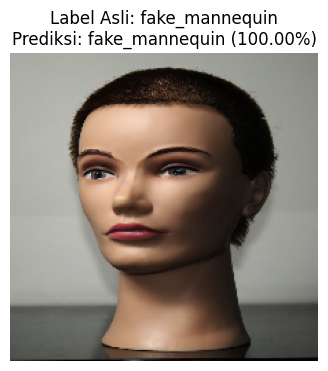

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


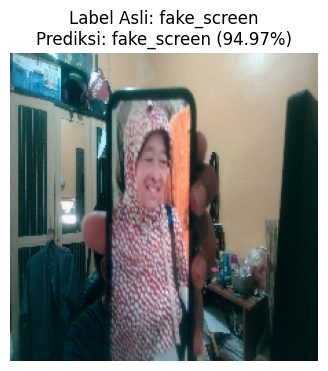

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
import random

# 1. Pastikan Path Model Benar
MODEL_PATH = '/kaggle/working/model_final.keras'
MODEL_PATH = 'model_final_v1.2.keras'
TEST_DIR = '/kaggle/working/val_clean_eval_v2' # Gunakan folder bersih Anda
TEST_DIR = 'Data/val' # Gunakan folder bersih Anda
TEST_DIR = 'Data/realcase' # Gunakan folder bersih Anda


# 2. Muat model yang telah diekspor
print("Memuat model untuk Inference...")
inference_model = tf.keras.models.load_model(MODEL_PATH)

# Daftar kelas
class_names = ['fake_mannequin', 'fake_mask', 'fake_papercut', 'fake_printed', 'fake_screen', 'realperson']

# 3. Ambil satu gambar acak dari folder untuk dites
TEST_COUNT = 10
for _ in range(TEST_COUNT):  # Uji dengan 5 gambar acak
    random_class = random.choice(class_names)
    class_dir = os.path.join(TEST_DIR, random_class)
    random_image_file = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, random_image_file)

    # 4. Fungsi Inference
    def predict_image(img_path, model):
        # Memuat gambar dan meresize sesuai input model (224x224)
        img = image.load_img(img_path, target_size=(224, 224))
        
        # Konversi ke array dan tambah dimensi batch (1, 224, 224, 3)
        img_array = image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)
        
        # Melakukan prediksi
        predictions = model.predict(img_batch)
        
        # Mendapatkan hasil
        predicted_idx = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        predicted_label = class_names[predicted_idx]
        
        # Visualisasi
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Label Asli: {random_class}\nPrediksi: {predicted_label} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()


    predict_image(img_path, inference_model)